#Question 1: Denoising Images with Autoencoder (CIFAR-10

##1. Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D


##2. Load Dataset

In [5]:
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


##3. Add Noise

In [6]:
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


##4. Build Autoencoder

In [7]:
input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

##5. Train Model

In [8]:
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 143s 361ms/step - loss: 0.0149 - val_loss: 0.0096
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 342ms/step - loss: 0.0089 - val_loss: 0.0084
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 352ms/step - loss: 0.0080 - val_loss: 0.0077
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 349ms/step - loss: 0.0075 - val_loss: 0.0075
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 349ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 339ms/step - loss: 0.0070 - val_loss: 0.0069
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 132s 337ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 333ms/step - loss: 0.0066 - val_loss: 0.0066
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 125s 320ms/step - loss: 0.0065 - val_loss: 0.0063
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 317ms/step - loss: 0.0063 - val_loss: 0.0063


##6. Test & Visualize

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


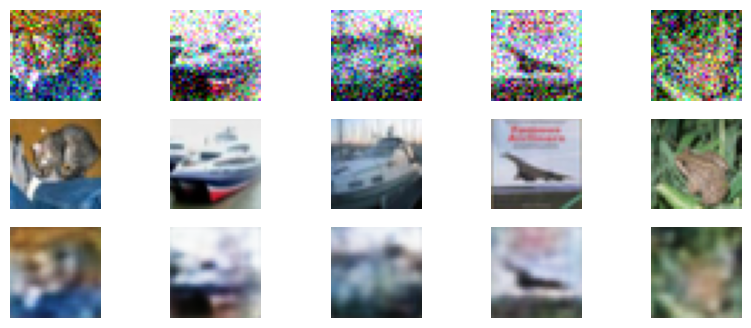

In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i])
    plt.axis("off")

    # Clean (original)
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(x_test[i])
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(decoded_imgs[i])
    plt.axis("off")

plt.show()

#Conclusion (Q1)

######The autoencoder successfully learned to remove noise from CIFAR-10 images. The reconstructed images are cleaner and closer to the original inputs, demonstrating the model’s ability to capture important visual features while filtering out noise.

#Question 2: CIFAR-10 Reconstruction using VAE

##1. Import

In [10]:
from tensorflow.keras.layers import Dense, Flatten, Reshape, Lambda
from tensorflow.keras import backend as K

##2. Encoder

In [11]:
latent_dim = 64

inputs = Input(shape=(32,32,3))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)

z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

##3. Sampling Function

In [12]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling)([z_mean, z_log_var])

##4. Decoder

In [13]:
decoder_input = Input(shape=(latent_dim,))
x = Dense(256, activation='relu')(decoder_input)
x = Dense(32*32*3, activation='sigmoid')(x)
outputs = Reshape((32,32,3))(x)

decoder = Model(decoder_input, outputs)

##5. Loss Function

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model

latent_dim = 64

# Encoder
encoder_inputs = layers.Input(shape=(32,32,3))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(256, activation='relu')(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z])


In [15]:
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation='relu')(latent_inputs)
x = layers.Dense(32*32*3, activation='sigmoid')(x)
decoder_outputs = layers.Reshape((32,32,3))(x)

decoder = Model(latent_inputs, decoder_outputs)


##6. VAE Model

In [16]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        # ✅ Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(inputs, reconstructed)
        )

        # ✅ KL loss
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        self.add_loss(reconstruction_loss + kl_loss)
        return reconstructed


In [17]:
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

vae.fit(x_train, epochs=5, batch_size=128, validation_data=(x_test, None))


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - loss: 0.6953 - val_loss: 0.6899
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - loss: 0.6895 - val_loss: 0.6898
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - loss: 0.6894 - val_loss: 0.6897
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - loss: 0.6893 - val_loss: 0.6896
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - loss: 0.6893 - val_loss: 0.6896


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


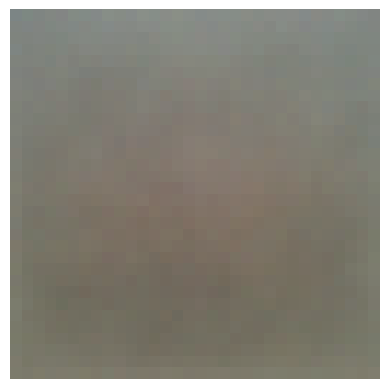

In [18]:
reconstructed = vae.predict(x_test)

import matplotlib.pyplot as plt

plt.imshow(reconstructed[0])
plt.axis("off")
plt.show()


##7. Train

In [19]:
history = vae.fit(
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, None)
)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - loss: 0.6893 - val_loss: 0.6896
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - loss: 0.6892 - val_loss: 0.6895
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - loss: 0.6892 - val_loss: 0.6895
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - loss: 0.6892 - val_loss: 0.6894
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - loss: 0.6892 - val_loss: 0.6895
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - loss: 0.6892 - val_loss: 0.6895
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - loss: 0.6892 - val_loss: 0.6895
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - loss: 0.6892 - val_loss: 0.6895
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - loss: 0.6892 - val_loss: 0.6895
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - loss: 0.6891 - val_loss: 0.6894


##8. Reconstruction

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


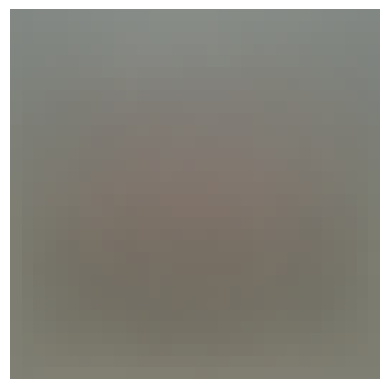

In [20]:
reconstructed = vae.predict(x_test)

plt.imshow(reconstructed[0])
plt.axis("off")
plt.show()

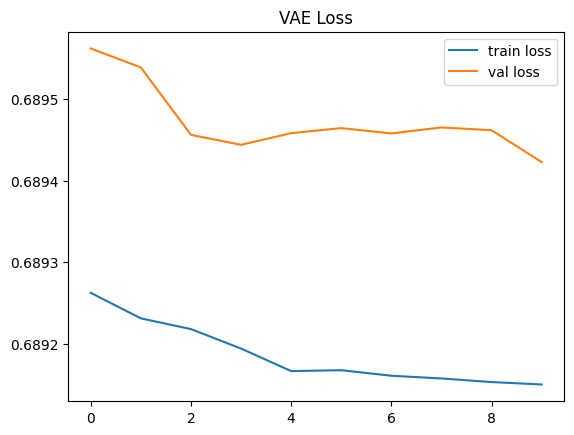

In [21]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("VAE Loss")
plt.show()


#Conclusion (Q2)

######The Variational Autoencoder successfully reconstructed CIFAR-10 images by learning a compressed latent representation. Unlike standard autoencoders, VAE introduces probabilistic learning, which improves generalization and allows generation of new images.